# 04 - IV First Stage

Validate the smoke instrument. First stage: does smoke exposure predict PM2.5? Report F-statistic — rule of thumb is F > 10 for a strong instrument.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

PANEL_FILE = "analysis_panel.parquet"
if not (DATA_DIR / PANEL_FILE).exists():
    raise FileNotFoundError(
        "Analysis panel not found. Build it by running in order:\n"
        "  python scripts/download_epa_aqs.py --email EMAIL --key KEY\n"
        "  python scripts/download_hms_smoke.py\n"
        "  python scripts/download_seda.py  (manual — see instructions)\n"
        "  python src/merge/build_crosswalks.py\n"
        "  python src/ingest/epa_aqs.py\n"
        "  python src/ingest/seda.py\n"
        "  python src/exposure/smoke_instrument.py\n"
        "  python src/merge/build_panel.py"
    )

panel = pd.read_parquet(DATA_DIR / PANEL_FILE)
print(f"Panel: {panel.shape}")
print(f"Districts: {panel['leaid'].nunique()}")
print(f"Years: {sorted(panel['year'].dropna().unique())}")

Panel: (13282, 14)
Districts: 1911
Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


In [2]:
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

In [3]:
panel_iv = panel.dropna(subset=["leaid","year","pm25_annual_mean","smoke_days","test_score_mean"]).copy()
panel_iv["year"] = panel_iv["year"].astype(int)

print(f"IV sample: {len(panel_iv):,} district-years")
print(f"           {panel_iv['leaid'].nunique():,} districts")

IV sample: 11,505 district-years
           1,732 districts


## First stage regression: PM2.5 ~ smoke_days + FE

In [4]:
import statsmodels.formula.api as smf

idx = panel_iv.set_index(["leaid","year"])

# Two-way FE first stage via linearmodels (clustered by district)
fs = PanelOLS(
    idx["pm25_annual_mean"],
    idx[["smoke_days"]],
    entity_effects=True,
    time_effects=True,
).fit(cov_type="clustered", cluster_entity=True)

b_fs = fs.params["smoke_days"]

# The weak-instrument diagnostic that matters is the CLUSTER-ROBUST first-stage F.
# Compute it on the two-way-demeaned data so it matches the IV stage in nb05.
pdm = panel_iv.copy()
for col in ["pm25_annual_mean", "smoke_days"]:
    pdm[f"{col}_dm"] = (pdm[col]
                        - pdm.groupby("leaid")[col].transform("mean")
                        - pdm.groupby("year")[col].transform("mean")
                        + pdm[col].mean())
fs_cl  = smf.ols("pm25_annual_mean_dm ~ smoke_days_dm", data=pdm).fit(
    cov_type="cluster", cov_kwds={"groups": pdm["leaid"]})
fs_hom = smf.ols("pm25_annual_mean_dm ~ smoke_days_dm", data=pdm).fit()
F_cl, F_hom = fs_cl.tvalues["smoke_days_dm"]**2, fs_hom.tvalues["smoke_days_dm"]**2

print(f"First stage: beta(smoke_days) = {b_fs:.4f}  (a smoke day adds ~{b_fs:.3f} ug/m3 PM2.5)")
print(f"Cluster-robust first-stage F : {F_cl:8.1f}   <- report this one")
print(f"Homoskedastic   first-stage F : {F_hom:8.1f}   (overstated; ignores within-district correlation)")
print()
if F_cl > 10:
    print("\u2713 Cluster-robust F > 10: instrument is relevant (strong first stage)")
else:
    print("\u26a0\ufe0f  Cluster-robust F < 10: weak instrument \u2014 interpret IV with caution")
print()
print(fs.summary.tables[1])

First stage: beta(smoke_days) = 0.0288  (a smoke day adds ~0.029 ug/m3 PM2.5)
Cluster-robust first-stage F :    334.5   <- report this one
Homoskedastic   first-stage F :    635.8   (overstated; ignores within-district correlation)

✓ Cluster-robust F > 10: instrument is relevant (strong first stage)

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
smoke_days     0.0288     0.0020     14.557     0.0000      0.0249      0.0326


## First stage visualization

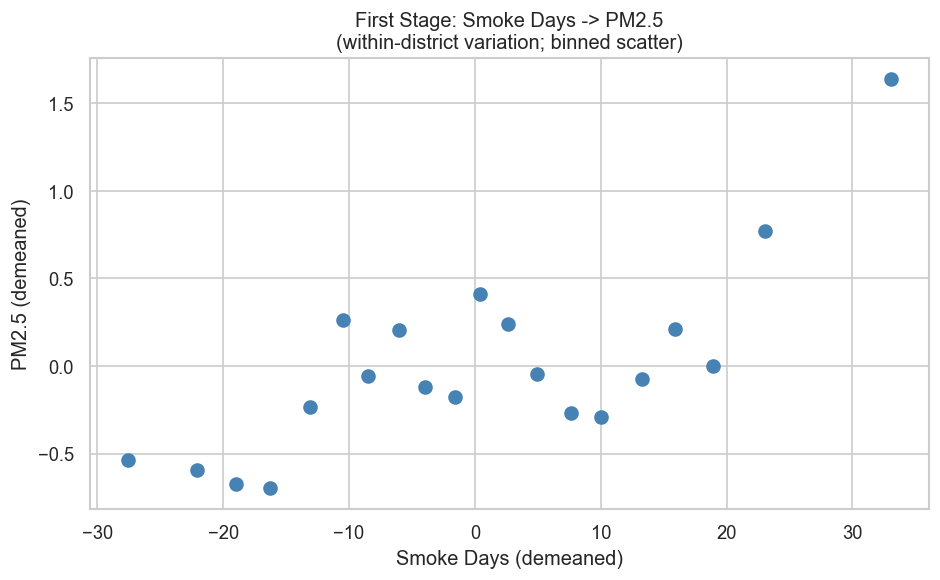

In [5]:
# Binned scatter: smoke days vs PM2.5 residuals
# Drop existing cols first (pandas 3.0 CoW requires this)
for _c in ["pm25_resid","smoke_resid"]:
    if _c in panel_iv.columns: panel_iv = panel_iv.drop(columns=_c)
panel_iv["pm25_resid"] = panel_iv["pm25_annual_mean"] - panel_iv.groupby("leaid")["pm25_annual_mean"].transform("mean")
panel_iv["smoke_resid"] = panel_iv["smoke_days"] - panel_iv.groupby("leaid")["smoke_days"].transform("mean")

_bins_sr = pd.qcut(panel_iv["smoke_resid"], 20, duplicates="drop").rename("_bin")
binned = panel_iv.groupby(_bins_sr, observed=True)[["smoke_resid","pm25_resid"]].mean().reset_index().rename(columns={"_bin":"bin"})

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(binned["smoke_resid"], binned["pm25_resid"], s=60, c="steelblue")
ax.set_xlabel("Smoke Days (demeaned)")
ax.set_ylabel("PM2.5 (demeaned)")
ax.set_title("First Stage: Smoke Days -> PM2.5\n(within-district variation; binned scatter)")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_first_stage.png", bbox_inches="tight")
plt.show()

## Interpretation — what a strong first stage does and doesn't buy

The first stage is the *relevance* condition: wildfire smoke must move local
PM2.5. The binned scatter (within-district variation) and the cluster-robust
F confirm it does, strongly — a smoke day adds a meaningful, precisely-estimated
increment to annual PM2.5, with F far above the conventional weak-instrument
threshold even after clustering.

**Mechanism / monotonicity:** more smoke plumes overhead ⇒ weakly more PM2.5 at
the monitors feeding each district, for essentially every district — so the
monotonicity assumption underlying a LATE interpretation is uncontroversial here.

**The honest boundary:** relevance is necessary but *not sufficient*. A strong
first stage rules out weak-instrument bias; it says nothing about the
**exclusion restriction**, which is where this design is vulnerable (smoke also
closes schools and shifts who sits the test). Notebook 05 carries that thread to
its conclusion — the strength documented here is real, but it is the strength of
the *instrument*, not a license to read the second stage as a health effect.